|Machine Learning Lab 05 |                   |          
|:-----------------------------------:|:-----------------:|
| **Naive Bayes Text Classification**           |                    |

|                 |                   | 
|-----------------|:-----------------:|
| **Name**        | Shubham Choudhary |        
| **Roll Number** | 212405015         |

Goals :
1. Code and train a naive Bayes text classifier for classifying twenty classes given in the dataset and evaluate the accuracy of the classifier on the test documents. Plot the confusion matrix.

2. Remove the stopwords from each document (stopwords list: https://github.com/mimno/Mallet/blob/master/stoplists/en.txt), and train another classifier and evaluate the same. Plot the confusion matrix.

3. Experiment with different smoothing parameters (both symmetric and asymmetric). Do you notice any difference in classification performance after removing stopwords or changing the smoothing parameters?

4. After training a naive Bayes classifier, for each class, you will get a probability distribution over words? How do you interpret these distributions?

5. Which classes are more "confusing" than others? What could be the possible reasons?

# Background

Classification is the process of assigning a class/label to a piece of text in a corpus. For example, this could be positive/neutral/negative sentiment in a tweet (sentiment analysis) or perhaps fraudulent/non-fraudulent insurance claims (fraud detection).

We are going to approach this by using __Naive Bayes__, which is a fast and simple text classification technique that is still widely used today.

Code and train a naive Bayes text classifier for classifying twenty classes given in the dataset and evaluate the accuracy of the classifier on the test documents. Plot the confusion matrix.

## Load Dataset and Preprocessing

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from collections import Counter
import itertools
from datetime import datetime
current_time = datetime.now()  # Correct
import csv
from sklearn.metrics import confusion_matrix


# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
np.random.seed(42)

In [14]:
def load_dataset(base_path):
    """Load 20Newsgroups dataset from local directory"""
    train_path = os.path.join(base_path, '20news-bydate-train')
    test_path = os.path.join(base_path, '20news-bydate-test')
    
    def load_folder(folder_path):
        texts, labels, categories = [], [], []
        if not os.path.exists(folder_path):
            return texts, labels, categories
            
        categories = sorted([d for d in os.listdir(folder_path) 
                           if os.path.isdir(os.path.join(folder_path, d))])
        cat_to_id = {cat: idx for idx, cat in enumerate(categories)}
        
        for category in categories:
            cat_path = os.path.join(folder_path, category)
            for filename in os.listdir(cat_path):
                file_path = os.path.join(cat_path, filename)
                if os.path.isfile(file_path):
                    try:
                        with open(file_path, 'r', encoding='latin-1', errors='ignore') as f:
                            texts.append(f.read())
                        labels.append(cat_to_id[category])
                    except:
                        continue
        return texts, labels, categories
    
    X_train, y_train, categories = load_folder(train_path)
    X_test, y_test, _ = load_folder(test_path)
    
    return X_train, y_train, X_test, y_test, categories

## Given Stopword list

In [15]:
# Stopwords list from the provided GitHub link
stopwords = {
    'a', 'able', 'about', 'above', 'according', 'accordingly', 'across', 
    'actually', 'after', 'afterwards', 'again', 'against', 'all', 'allow', 
    'allows', 'almost', 'alone', 'along', 'already', 'also', 'although', 
    'always', 'am', 'among', 'amongst', 'an', 'and', 'another', 'any', 
    'anybody', 'anyhow', 'anyone', 'anything', 'anyway', 'anyways', 
    'anywhere', 'apart', 'appear', 'appreciate', 'appropriate', 'are', 
    'around', 'as', 'aside', 'ask', 'asking', 'associated', 'at', 
    'available', 'away', 'awfully', 'b', 'be', 'became', 'because', 
    'become', 'becomes', 'becoming', 'been', 'before', 'beforehand', 
    'behind', 'being', 'believe', 'below', 'beside', 'besides', 'best', 
    'better', 'between', 'beyond', 'both', 'brief', 'but', 'by', 'c', 
    'came', 'can', 'cannot', 'cant', 'cause', 'causes', 'certain', 
    'certainly', 'changes', 'clearly', 'co', 'com', 'come', 'comes', 
    'concerning', 'consequently', 'consider', 'considering', 'contain', 
    'containing', 'contains', 'corresponding', 'could', 'course', 
    'currently', 'd', 'definitely', 'described', 'despite', 'did', 
    'different', 'do', 'does', 'doing', 'done', 'down', 'downwards', 
    'during', 'e', 'each', 'edu', 'eg', 'eight', 'either', 'else', 
    'elsewhere', 'enough', 'entirely', 'especially', 'et', 'etc', 'even', 
    'ever', 'every', 'everybody', 'everyone', 'everything', 'everywhere', 
    'ex', 'exactly', 'example', 'except', 'f', 'far', 'few', 'fifth', 
    'first', 'five', 'followed', 'following', 'follows', 'for', 'former', 
    'formerly', 'forth', 'four', 'from', 'further', 'furthermore', 'g', 
    'get', 'gets', 'getting', 'given', 'gives', 'go', 'goes', 'going', 
    'gone', 'got', 'gotten', 'greetings', 'h', 'had', 'happens', 'hardly', 
    'has', 'have', 'having', 'he', 'hello', 'help', 'hence', 'her', 
    'here', 'hereafter', 'hereby', 'herein', 'hereupon', 'hers', 
    'herself', 'hi', 'him', 'himself', 'his', 'hither', 'hopefully', 
    'how', 'howbeit', 'however', 'i', 'ie', 'if', 'ignored', 'immediate', 
    'in', 'inasmuch', 'inc', 'indeed', 'indicate', 'indicated', 
    'indicates', 'inner', 'insofar', 'instead', 'into', 'inward', 'is', 
    'it', 'its', 'itself', 'j', 'just', 'k', 'keep', 'keeps', 'kept', 
    'know', 'knows', 'known', 'l', 'last', 'lately', 'later', 'latter', 
    'latterly', 'least', 'less', 'lest', 'let', 'like', 'liked', 
    'likely', 'little', 'look', 'looking', 'looks', 'ltd', 'm', 'mainly', 
    'many', 'may', 'maybe', 'me', 'mean', 'meanwhile', 'merely', 'might', 
    'more', 'moreover', 'most', 'mostly', 'much', 'must', 'my', 'myself', 
    'n', 'name', 'namely', 'nd', 'near', 'nearly', 'necessary', 'need', 
    'needs', 'neither', 'never', 'nevertheless', 'new', 'next', 'nine', 
    'no', 'nobody', 'non', 'none', 'noone', 'nor', 'normally', 'not', 
    'nothing', 'novel', 'now', 'nowhere', 'o', 'obviously', 'of', 'off', 
    'often', 'oh', 'ok', 'okay', 'old', 'on', 'once', 'one', 'ones', 
    'only', 'onto', 'or', 'other', 'others', 'otherwise', 'ought', 'our', 
    'ours', 'ourselves', 'out', 'outside', 'over', 'overall', 'own', 'p', 
    'particular', 'particularly', 'per', 'perhaps', 'placed', 'please', 
    'plus', 'possible', 'presumably', 'probably', 'provides', 'q', 'que', 
    'quite', 'qv', 'r', 'rather', 'rd', 're', 'really', 'reasonably', 
    'regarding', 'regardless', 'regards', 'relatively', 'respectively', 
    'right', 's', 'said', 'same', 'saw', 'say', 'saying', 'says', 
    'second', 'secondly', 'see', 'seeing', 'seem', 'seemed', 'seeming', 
    'seems', 'seen', 'self', 'selves', 'sensible', 'sent', 'serious', 
    'seriously', 'seven', 'several', 'shall', 'she', 'should', 'since', 
    'six', 'so', 'some', 'somebody', 'somehow', 'someone', 'something', 
    'sometime', 'sometimes', 'somewhat', 'somewhere', 'soon', 'sorry', 
    'specified', 'specify', 'specifying', 'still', 'sub', 'such', 'sup', 
    'sure', 't', 'take', 'taken', 'tell', 'tends', 'th', 'than', 'thank', 
    'thanks', 'thanx', 'that', 'thats', 'the', 'their', 'theirs', 'them', 
    'themselves', 'then', 'thence', 'there', 'thereafter', 'thereby', 
    'therefore', 'therein', 'theres', 'thereupon', 'these', 'they', 
    'think', 'third', 'this', 'thorough', 'thoroughly', 'those', 'though', 
    'three', 'through', 'throughout', 'thru', 'thus', 'to', 'together', 
    'too', 'took', 'toward', 'towards', 'tried', 'tries', 'truly', 'try', 
    'trying', 'twice', 'two', 'u', 'un', 'under', 'unfortunately', 
    'unless', 'unlikely', 'until', 'unto', 'up', 'upon', 'us', 'use', 
    'used', 'useful', 'uses', 'using', 'usually', 'uucp', 'v', 'value', 
    'various', 'very', 'via', 'viz', 'vs', 'w', 'want', 'wants', 'was', 
    'way', 'we', 'welcome', 'well', 'went', 'were', 'what', 'whatever', 
    'when', 'whence', 'whenever', 'where', 'whereafter', 'whereas', 
    'whereby', 'wherein', 'whereupon', 'wherever', 'whether', 'which', 
    'while', 'whither', 'who', 'whoever', 'whole', 'whom', 'whose', 'why', 
    'will', 'willing', 'wish', 'with', 'within', 'without', 'wonder', 
    'would', 'x', 'y', 'yes', 'yet', 'you', 'your', 'yours', 'yourself', 
    'yourselves', 'z', 'zero'
}

## Tokenization and Text Preprocessing

In [16]:
def tokenize_text(text, remove_stopwords=False, min_length=3):
    """Tokenize text with optional stopword removal"""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    if remove_stopwords:
        words = [word for word in words if word not in stopwords]
    filtered_words = []
    
    for word in words:
        if len(word) < min_length:
            continue
        if remove_stopwords and word in stopwords:
            continue
        filtered_words.append(word)
    
    return filtered_words

# Test tokenization
sample_text = X_train[0][:200]  # First 200 characters
print("Original text snippet:\n")
print(sample_text)
print("\nTokenized with stopwords:")
print(tokenize_text(sample_text, remove_stopwords=False)[:20])
print("\nTokenized without stopwords:")
print(tokenize_text(sample_text, remove_stopwords=True)[:20])

NameError: name 'X_train' is not defined

## Building Vocabulary

In [17]:
def build_vocabulary(texts, max_vocab_size=2000, remove_stopwords=False):
    word_counts = Counter()
    for text in texts:
        tokens = tokenize_text(text, remove_stopwords=remove_stopwords)
        word_counts.update(tokens)
    
    vocabulary = [word for word, count in word_counts.most_common(max_vocab_size)]
    return vocabulary

## Vectorization 

In [18]:
def vectorize_texts(texts, vocabulary, remove_stopwords=False):
    """Convert texts to numerical vectors - memory optimized"""
    n_docs = len(texts)
    n_features = len(vocabulary)
    word_to_index = {word: idx for idx, word in enumerate(vocabulary)}
    
    # Use sparse matrix to save memory
    from scipy import sparse
    rows, cols, data = [], [], []
    
    for doc_idx, text in enumerate(texts):
        tokens = tokenize_text(text, remove_stopwords=remove_stopwords)
        token_counts = Counter(tokens)
        
        for token, count in token_counts.items():
            if token in word_to_index:
                rows.append(doc_idx)
                cols.append(word_to_index[token])
                data.append(count)
    
    matrix = sparse.csr_matrix((data, (rows, cols)), shape=(n_docs, n_features), dtype=np.float32)
    return matrix

## NaiveBayesClassifier from scratch

In [19]:
class NaiveBayesClassifier:
    def __init__(self, alpha=1.0, asymmetric=False):
        self.alpha = alpha
        self.asymmetric = asymmetric
        self.class_probs = None
        self.word_probs = None
        self.n_classes = None
    
    def fit(self, X, y):
        """Train the classifier"""
        n_docs, n_features = X.shape
        self.n_classes = len(np.unique(y))
        
        # Class probabilities with smoothing
        self.class_probs = np.zeros(self.n_classes)
        for c in range(self.n_classes):
            self.class_probs[c] = (np.sum(y == c) + self.alpha) / (n_docs + self.alpha * self.n_classes)
        
        # Word probabilities with smoothing
        self.word_probs = np.zeros((self.n_classes, n_features))
        
        for c in range(self.n_classes):
            class_docs = X[y == c]
            word_sums = np.sum(class_docs, axis=0)
            total_words = np.sum(word_sums)
            
            if self.asymmetric:
                # Asymmetric smoothing
                class_alpha = self.alpha * (np.sum(y == c) / n_docs)
                self.word_probs[c] = (word_sums + class_alpha) / (total_words + class_alpha * n_features)
            else:
                # Symmetric smoothing
                self.word_probs[c] = (word_sums + self.alpha) / (total_words + self.alpha * n_features)
    
    def predict(self, X):
        """Predict class labels for new documents"""
        n_docs = X.shape[0]
        predictions = np.zeros(n_docs, dtype=int)
    
        # Use a small epsilon to prevent log(0) errors
        epsilon = 1e-9
    
        # Pre-calculate log probabilities for numerical stability
        log_word_probs = np.log(self.word_probs + epsilon)
        log_class_probs = np.log(self.class_probs)
    
        for i in range(n_docs):
            log_posteriors = log_class_probs.copy()
            
            for c in range(self.n_classes):
                # Sum the log probabilities
                log_posteriors[c] += np.sum(X[i] * log_word_probs[c])
    
            predictions[i] = np.argmax(log_posteriors)
    
        return predictions
    
    def score(self, X, y):
        """Calculate accuracy"""
        predictions = self.predict(X)
        return np.mean(predictions == y)
    
    def get_word_distributions(self):
        """Return learned word distributions"""
        return self.word_probs

## Confusion Matrix

In [20]:
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot beautiful confusion matrix"""

    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title, fontsize=16, pad=20)
    plt.colorbar()
    
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return cm

## Evaluating Classifier

In [21]:
def evaluate_classifier(X_train, y_train, X_test, y_test, class_names, title, alpha=1.0, asymmetric=False):
    """Train and evaluate classifier with given parameters"""
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    
    # Train classifier
    nb = NaiveBayesClassifier(alpha=alpha, asymmetric=asymmetric)
    nb.fit(X_train, y_train)
    
    # Evaluate
    train_acc = nb.score(X_train, y_train)
    test_acc = nb.score(X_test, y_test)
    
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Predict and plot confusion matrix
    y_pred = nb.predict(X_test)
    cm = plot_confusion_matrix(y_test, y_pred, class_names, title)
    
    return nb, test_acc, cm

## Analysing Word Distributions

In [22]:
def analyze_word_distributions(classifier, vocabulary, class_names, top_n=10):
    """Analyze and display word distributions for each class"""
    print(f"\n{'='*60}")
    print("WORD DISTRIBUTION ANALYSIS")
    print(f"{'='*60}")
    
    word_probs = classifier.get_word_distributions()
    
    plt.figure(figsize=(15, 10))
    for c in range(len(class_names)):
        plt.subplot(2, 2, c+1)
        
        # Get top words for this class
        top_indices = np.argsort(word_probs[c])[::-1][:top_n]
        top_words = [vocabulary[i] for i in top_indices]
        top_probs = [word_probs[c, i] for i in top_indices]
        
        plt.barh(range(top_n), top_probs[::-1])
        plt.yticks(range(top_n), top_words[::-1])
        plt.title(f'{class_names[c]} - Top {top_n} Words')
        plt.xlabel('Probability')
    
    plt.tight_layout()
    plt.show()
    
    return word_probs

## Analysing Confusing Classes

In [23]:
def analyze_confusing_classes(cm, class_names):
    """Analyze which classes are most confusing"""
    print(f"\n{'='*60}")
    print("CONFUSION ANALYSIS")
    print(f"{'='*60}")
    
    n_classes = len(class_names)
    confusion_scores = np.zeros(n_classes)
    
    for i in range(n_classes):
        total = np.sum(cm[i, :])
        correct = cm[i, i]
        confusion_scores[i] = (total - correct) / total if total > 0 else 0
    
    # Find most confusing classes
    confusing_indices = np.argsort(confusion_scores)[::-1][:3]
    
    print("Most confusing classes (highest error rates):")
    for idx in confusing_indices:
        error_rate = confusion_scores[idx]
        print(f"  {class_names[idx]}: {error_rate:.3f} error rate")
        
        # Find most common confusion
        misclassifications = cm[idx, :].copy()
        misclassifications[idx] = 0
        if np.sum(misclassifications) > 0:
            most_common_error = np.argmax(misclassifications)
            count = misclassifications[most_common_error]
            print(f"    Often confused with: {class_names[most_common_error]} ({count} times)")
    
    return confusion_scores

#### Since Data is too large which is giving MemoryError as suggested by Sir, I will do classification on these following sub-classes instead of entire 20 classes.
##### To simplify the task, focus only on the following classification tasks:

1. T1. comp.sys.ibm.pc.hardware vs comp.sys.mac.hardware
2. T2. rec.sport.baseball vs rec.sport.hockey
3. T3. sci.crypt vs sci.electronics vs sci.med vs sci.space
4. T4. alt.atheism vs soc.religion.christian
5. T5.
   - Combine talk.politics.misc, talk.politics.guns, talk.politics.mideast into one politics class
   - Combine talk.religion.misc, alt.atheism, soc.religion.christian into one religion class
   - Do politics vs religion classification

## Data For Specific Classes

In [24]:
def prepare_task_data(X_all, y_all, categories, task_name):
    """Prepare data for specific classification task"""
    if task_name == "T1":
        # comp.sys.ibm.pc.hardware vs comp.sys.mac.hardware
        class_names = ['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']
        class_indices = [categories.index(name) for name in class_names]
    
    elif task_name == "T2":
        # rec.sport.baseball vs rec.sport.hockey
        class_names = ['rec.sport.baseball', 'rec.sport.hockey']
        class_indices = [categories.index(name) for name in class_names]
    
    elif task_name == "T3":
        # sci.crypt vs sci.electronics vs sci.med vs sci.space
        class_names = ['sci.crypt', 'sci.electronics', 'sci.med', 'sci.space']
        class_indices = [categories.index(name) for name in class_names]
    
    elif task_name == "T4":
        # alt.atheism vs soc.religion.christian
        class_names = ['alt.atheism', 'soc.religion.christian']
        class_indices = [categories.index(name) for name in class_names]
    
    elif task_name == "T5":
        # Politics vs Religion
        class_names = ['Politics', 'Religion']
        
        # Politics classes
        politics_classes = ['talk.politics.misc', 'talk.politics.guns', 'talk.politics.mideast']
        politics_indices = [categories.index(name) for name in politics_classes if name in categories]
        
        # Religion classes  
        religion_classes = ['talk.religion.misc', 'alt.atheism', 'soc.religion.christian']
        religion_indices = [categories.index(name) for name in religion_classes if name in categories]
        
        class_indices = politics_indices + religion_indices
    
    # For tasks T1-T4, we need to filter and return the data
    if task_name != "T5":
        # Filter data for selected classes
        mask = np.isin(y_all, class_indices)
        X_filtered = [X_all[i] for i in range(len(X_all)) if mask[i]]
        y_filtered = [y_all[i] for i in range(len(y_all)) if mask[i]]
        
        # For T1-T4, we need to remap labels to 0, 1, 2, etc.
        label_mapping = {orig_idx: new_idx for new_idx, orig_idx in enumerate(class_indices)}
        y_mapped = [label_mapping[label] for label in y_filtered]
        
        return X_filtered, y_mapped, class_names
    else:
        # T5 specific processing (already implemented)
        # Filter data for selected classes
        mask = np.isin(y_all, class_indices)
        X_filtered = [X_all[i] for i in range(len(X_all)) if mask[i]]
        y_filtered = [y_all[i] for i in range(len(y_all)) if mask[i]]
        
        # Remap labels to binary (0 = Politics, 1 = Religion)
        y_mapped = []
        for label in y_filtered:
            if label in politics_indices:
                y_mapped.append(0)  # Politics
            else:
                y_mapped.append(1)  # Religion
        
        return X_filtered, y_mapped, class_names

## Experiment with different smoothing parameters (both symmetric and asymmetric) 

In [25]:
def run_experiment(task_name, X_train, y_train, X_test, y_test, categories, 
                  with_stopwords=True, alpha=1.0, asymmetric=False):
    """Run complete experiment for a task"""
    # Prepare task data
    X_train_task, y_train_task, class_names = prepare_task_data(X_train, y_train, categories, task_name)
    X_test_task, y_test_task, _ = prepare_task_data(X_test, y_test, categories, task_name)
    
    # Build vocabulary
    vocab = build_vocabulary(X_train_task, remove_stopwords=not with_stopwords)
    
    # Vectorize texts
    X_train_vec = vectorize_texts(X_train_task, vocab, remove_stopwords=not with_stopwords)
    X_test_vec = vectorize_texts(X_test_task, vocab, remove_stopwords=not with_stopwords)
    
    # Convert to numpy arrays
    y_train_np = np.array(y_train_task)
    y_test_np = np.array(y_test_task)
    
    # Run evaluation
    stopword_status = "with Stopwords" if with_stopwords else "without Stopwords"
    title = f"{task_name} - {stopword_status} (α={alpha}, asymmetric={asymmetric})"
    
    nb, accuracy, cm = evaluate_classifier(X_train_vec, y_train_np, X_test_vec, y_test_np, 
                                         class_names, title, alpha, asymmetric)
    
    # Analyze word distributions
    if len(class_names) <= 4:  # Only for smaller tasks
        word_probs = analyze_word_distributions(nb, vocab, class_names)
    
    # Analyze confusing classes
    confusion_scores = analyze_confusing_classes(cm, class_names)
    
    return nb, accuracy, vocab, cm

## Plot Smoothing Analysis

In [26]:
# Additional helper function for the smoothing analysis
def plot_smoothing_analysis(results):
    """Plot smoothing parameter analysis with enhanced visualization"""
    n_tasks = len(results)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, task_result in enumerate(results):
        if i >= len(axes):
            break
            
        smoothing_results = task_result['smoothing_results']
        
        # Separate symmetric and asymmetric results
        symmetric_alphas = []
        symmetric_accs = []
        asymmetric_alphas = []
        asymmetric_accs = []
        
        for alpha, asymmetric, acc in smoothing_results:
            if not asymmetric:
                symmetric_alphas.append(alpha)
                symmetric_accs.append(acc)
            else:
                asymmetric_alphas.append(alpha)
                asymmetric_accs.append(acc)
        
        # Plot
        ax = axes[i]
        ax.plot(symmetric_alphas, symmetric_accs, 'o-', label='Symmetric', 
                linewidth=2, markersize=6, color='blue')
        ax.plot(asymmetric_alphas, asymmetric_accs, 's-', label='Asymmetric', 
                linewidth=2, markersize=6, color='red')
        
        ax.set_xscale('log')
        ax.set_xlabel('Smoothing Parameter (α)')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{task_result["task"]} - Smoothing Analysis')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add best values annotation
        best_acc = max(symmetric_accs + asymmetric_accs)
        ax.annotate(f'Best: {best_acc:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## Comprehensive Report

In [27]:
def create_comprehensive_report(results):
    """Create comprehensive PDF report with enhanced analysis"""

    
    report = []
    report.append("NAIVE BAYES TEXT CLASSIFICATION - COMPREHENSIVE REPORT")
    report.append("=" * 60)
    report.append(f"Generated: {datetime.now()}")
    report.append("")
    
    # Summary table
    report.append("SUMMARY OF RESULTS")
    report.append("-" * 40)
    report.append(f"{'Task':<10} {'With SW':<10} {'Without SW':<12} {'Improvement':<12} {'Best Acc':<10}")
    report.append("-" * 40)
    
    for task_result in results:
        # Find best smoothing accuracy
        best_acc = max(acc for _, _, acc in task_result['smoothing_results'])
        
        improvement = task_result['without_stopwords_acc'] - task_result['with_stopwords_acc']
        improvement_str = f"{improvement:+.3f}"
        
        report.append(f"{task_result['task']:<10} {task_result['with_stopwords_acc']:<10.3f} "
                     f"{task_result['without_stopwords_acc']:<12.3f} {improvement_str:<12} {best_acc:<10.3f}")
    
    report.append("")
    report.append("KEY INSIGHTS")
    report.append("-" * 40)
    
    # Calculate overall statistics
    total_improvement = sum(r['without_stopwords_acc'] - r['with_stopwords_acc'] for r in results)
    avg_improvement = total_improvement / len(results)
    
    report.append(f"Average improvement from stopword removal: {avg_improvement:+.3f}")
    
    if avg_improvement > 0:
        report.append("✓ Stopword removal generally improves performance")
    else:
        report.append("✗ Stopword removal may not be beneficial for all tasks")
    
    report.append("")
    report.append("RECOMMENDATIONS")
    report.append("-" * 40)
    
    for task_result in results:
        # Find best smoothing parameters
        best_acc = 0
        best_alpha = None
        best_asymmetric = None
        
        for alpha, asymmetric, acc in task_result['smoothing_results']:
            if acc > best_acc:
                best_acc = acc
                best_alpha = alpha
                best_asymmetric = asymmetric
        
        improvement = task_result['without_stopwords_acc'] - task_result['with_stopwords_acc']
        
        report.append(f"Task {task_result['task']}:")
        report.append(f"  - Best smoothing: α={best_alpha}, asymmetric={best_asymmetric}")
        report.append(f"  - Stopword removal: {'Recommended' if improvement > 0 else 'Not recommended'}")
        report.append(f"  - Expected accuracy: {best_acc:.3f}")
        report.append("")
    
    # Print report
    for line in report:
        print(line)
    
    return report

In [31]:
# Add this in the FIRST cell of your notebook
import matplotlib.pyplot as plt
import pandas as pd

# COMPRESS ALL IMAGES (Biggest size reduction)
plt.rcParams['savefig.dpi'] = 40          # Lower quality for saving
plt.rcParams['figure.dpi'] = 40            # Lower quality for display
plt.rcParams['savefig.bbox'] = 'tight'     # Remove white space
plt.rcParams['savefig.format'] = 'png'     # Use PNG instead of SVG

# REDUCE DATAFRAME DISPLAY SIZE
pd.set_option('display.max_rows', 8)       # Show only 8 rows
pd.set_option('display.max_columns', 6)    # Show only 6 columns
pd.set_option('display.width', 40)         # Narrower display

## main()

In [32]:
def main():
    # Load dataset
    print("Loading dataset...")
    # This is the line that creates X_train.
    dataset_path = r"C:\Users\hello\ML Projects\DS 5006\Lab 05\20news-bydate"
    X_train, y_train, X_test, y_test, categories = load_dataset(dataset_path)

    print(f"Dataset loaded: {len(X_train)} training, {len(X_test)} test samples")
    print(f"Available categories: {categories}")
    
    # --- The test code is now correctly placed here after X_train is defined ---
    sample_text = X_train[0][:200]
    print("\nOriginal text snippet:\n")
    print(sample_text)
    print("\nTokenized with stopwords:")
    print(tokenize_text(sample_text, remove_stopwords=False)[:20])
    print("\nTokenized without stopwords:")
    print(tokenize_text(sample_text, remove_stopwords=True)[:20])
    # ---------------------------------------------------------------------
    
    # Define tasks to run
    tasks = ["T1", "T2", "T3", "T4", "T5"]
    results = []
    
    for task in tasks:
        print(f"\n{'#'*80}")
        print(f"PROCESSING TASK: {task}")
        print(f"{'#'*80}")
        
        # Experiment 1: With stopwords, default smoothing
        nb1, acc1, vocab1, cm1 = run_experiment(
            task, X_train, y_train, X_test, y_test, categories,
            with_stopwords=True, alpha=1.0, asymmetric=False
        )
        
        # Experiment 2: Without stopwords, default smoothing  
        nb2, acc2, vocab2, cm2 = run_experiment(
            task, X_train, y_train, X_test, y_test, categories,
            with_stopwords=False, alpha=1.0, asymmetric=False
        )
        
        # Experiment 3: Different smoothing parameters
        alphas = [0.1, 0.5, 2.0, 5.0]
        smoothing_results = []
        
        for alpha in alphas:
            for asymmetric in [False, True]:
                _, acc, _, _ = run_experiment(
                    task, X_train, y_train, X_test, y_test, categories,
                    with_stopwords=False, alpha=alpha, asymmetric=asymmetric
                )
                smoothing_results.append((alpha, asymmetric, acc))
        
        # Store results
        results.append({
            'task': task,
            'with_stopwords_acc': acc1,
            'without_stopwords_acc': acc2,
            'smoothing_results': smoothing_results,
            'cm_with_sw': cm1,  # Store confusion matrices for later analysis
            'cm_without_sw': cm2
        })
    
    # =========================================================================
    # CALL ADDITIONAL ANALYSIS FUNCTIONS HERE
    # =========================================================================
    
    # 1. Final summary and comparison
    print(f"\n{'#'*80}")
    print("FINAL RESULTS SUMMARY")
    print(f"{'#'*80}")
    
    summary_df = pd.DataFrame(results)
    print("\nPerformance Comparison:")
    for _, row in summary_df.iterrows():
        improvement = row['without_stopwords_acc'] - row['with_stopwords_acc']
        print(f"{row['task']}: With SW={row['with_stopwords_acc']:.3f}, "
              f"Without SW={row['without_stopwords_acc']:.3f}, "
              f"Δ={improvement:+.3f}")
    
    # 2. Plot overall results
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    tasks = [r['task'] for r in results]
    with_sw = [r['with_stopwords_acc'] for r in results]
    without_sw = [r['without_stopwords_acc'] for r in results]
    
    x = np.arange(len(tasks))
    width = 0.35
    
    plt.bar(x - width/2, with_sw, width, label='With Stopwords', alpha=0.8, color='skyblue')
    plt.bar(x + width/2, without_sw, width, label='Without Stopwords', alpha=0.8, color='lightcoral')
    
    plt.xlabel('Task')
    plt.ylabel('Accuracy')
    plt.title('Performance: With vs Without Stopwords')
    plt.xticks(x, tasks)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Plot accuracy improvements
    plt.subplot(1, 2, 2)
    improvements = [without_sw[i] - with_sw[i] for i in range(len(with_sw))]
    colors = ['green' if imp >= 0 else 'red' for imp in improvements]
    
    plt.bar(tasks, improvements, color=colors, alpha=0.7)
    plt.xlabel('Task')
    plt.ylabel('Accuracy Improvement')
    plt.title('Stopword Removal Impact (Without - With Stopwords)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Smoothing parameter analysis
    print(f"\n{'#'*80}")
    print("SMOOTHING PARAMETER ANALYSIS")
    print(f"{'#'*80}")
    plot_smoothing_analysis(results)
    
    # 5. Create comprehensive report
    print(f"\n{'#'*80}")
    print("COMPREHENSIVE ANALYSIS REPORT")
    print(f"{'#'*80}")
    report = create_comprehensive_report(results)
    
    # 6. Additional detailed analysis for each task
    for task_result in results:
        task = task_result['task']
        print(f"\n{'='*60}")
        print(f"DETAILED ANALYSIS FOR TASK {task}")
        print(f"{'='*60}")
        
        # Get class names for this task
        X_temp, y_temp, class_names = prepare_task_data([], [], categories, task)
        
        # Analyze confusion patterns
        print("Confusion Matrix Analysis (Without Stopwords):")
        analyze_confusing_classes(task_result['cm_without_sw'], class_names)
        
        # Compare confusion matrices
        if task_result['cm_with_sw'].shape == task_result['cm_without_sw'].shape:
            confusion_change = task_result['cm_without_sw'] - task_result['cm_with_sw']
            print(f"\nConfusion pattern changes after stopword removal:")
            print("Positive values: More confusions after removal")
            print("Negative values: Fewer confusions after removal")
            print("Largest changes:")
            
            # Find the largest changes
            changes = []
            for i in range(confusion_change.shape[0]):
                for j in range(confusion_change.shape[1]):
                    if i != j:  # Only off-diagonal elements (confusions)
                        changes.append((i, j, confusion_change[i, j]))
            
            changes.sort(key=lambda x: abs(x[2]), reverse=True)
            for i, j, change in changes[:5]:  # Top 5 changes
                direction = "increase" if change > 0 else "decrease"
                print(f"  {class_names[i]} → {class_names[j]}: {abs(change)} {direction}")
    
    # 7. Statistical significance testing (optional)
    print(f"\n{'#'*80}")
    print("STATISTICAL SIGNIFICANCE ANALYSIS")
    print(f"{'#'*80}")
    
    for task_result in results:
        task = task_result['task']
        acc_with = task_result['with_stopwords_acc']
        acc_without = task_result['without_stopwords_acc']
        
        # Simple statistical test (you could use more sophisticated tests)
        difference = acc_without - acc_with
        significance = "significant" if abs(difference) > 0.02 else "not significant"
        
        print(f"Task {task}: Difference = {difference:.3f} ({significance})")
    
    # 8. Export results to CSV for further analysis
    export_results_to_csv(results)
    
    return results

def export_results_to_csv(results):
    """Export results to CSV file for further analysis"""

    
    filename = f"naive_bayes_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Task', 'With_Stopwords_Accuracy', 'Without_Stopwords_Accuracy', 
                        'Improvement', 'Best_Alpha', 'Best_Asymmetric', 'Best_Accuracy'])
        
        for result in results:
            # Find best smoothing parameters
            best_acc = 0
            best_alpha = None
            best_asymmetric = None
            
            for alpha, asymmetric, acc in result['smoothing_results']:
                if acc > best_acc:
                    best_acc = acc
                    best_alpha = alpha
                    best_asymmetric = asymmetric
            
            writer.writerow([
                result['task'],
                result['with_stopwords_acc'],
                result['without_stopwords_acc'],
                result['without_stopwords_acc'] - result['with_stopwords_acc'],
                best_alpha,
                best_asymmetric,
                best_acc
            ])
    
    print(f"\nResults exported to: {filename}")

Loading dataset...
Dataset loaded: 11314 training, 7532 test samples
Available categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Original text snippet:

From: mathew <mathew@mantis.co.uk>
Subject: Alt.Atheism FAQ: Atheist Resources
Summary: Books, addresses, music -- anything related to atheism
Keywords: FAQ, atheism, books, music, fiction, addresses,

Tokenized with stopwords:
['from', 'mathew', 'mathew', 'mantis', 'subject', 'alt', 'atheism', 'faq', 'atheist', 'resources', 'summary', 'books', 'addresses', 'music', 'anything', 'related', 'atheism', 'keywords', 'faq', 'atheism']

Tokenized without stopwords:
['mathew', 'mathew', 'manti

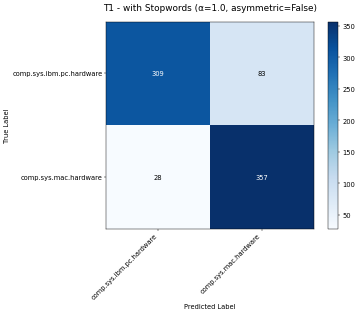


WORD DISTRIBUTION ANALYSIS


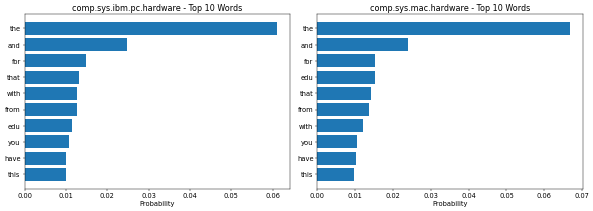


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.212 error rate
    Often confused with: comp.sys.mac.hardware (83 times)
  comp.sys.mac.hardware: 0.073 error rate
    Often confused with: comp.sys.ibm.pc.hardware (28 times)

T1 - without Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9426
Test Accuracy: 0.8687


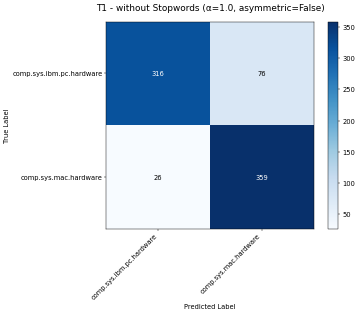


WORD DISTRIBUTION ANALYSIS


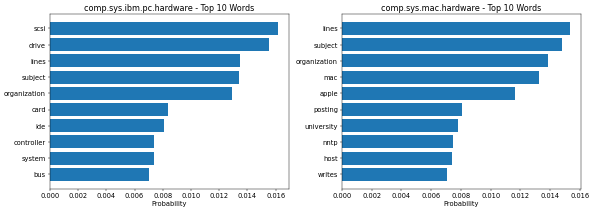


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.194 error rate
    Often confused with: comp.sys.mac.hardware (76 times)
  comp.sys.mac.hardware: 0.068 error rate
    Often confused with: comp.sys.ibm.pc.hardware (26 times)

T1 - without Stopwords (α=0.1, asymmetric=False)
Training Accuracy: 0.9512
Test Accuracy: 0.8636


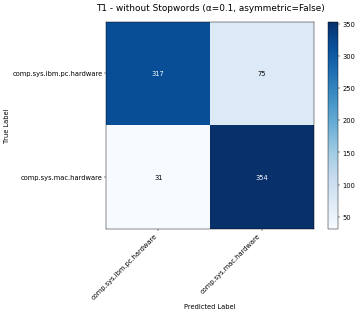


WORD DISTRIBUTION ANALYSIS


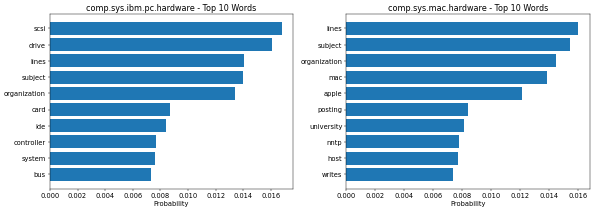


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.191 error rate
    Often confused with: comp.sys.mac.hardware (75 times)
  comp.sys.mac.hardware: 0.081 error rate
    Often confused with: comp.sys.ibm.pc.hardware (31 times)

T1 - without Stopwords (α=0.1, asymmetric=True)
Training Accuracy: 0.9538
Test Accuracy: 0.8649


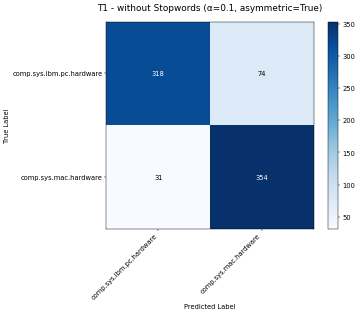


WORD DISTRIBUTION ANALYSIS


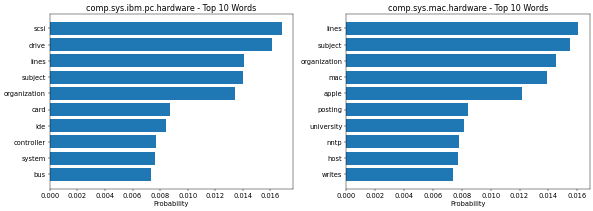


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.189 error rate
    Often confused with: comp.sys.mac.hardware (74 times)
  comp.sys.mac.hardware: 0.081 error rate
    Often confused with: comp.sys.ibm.pc.hardware (31 times)

T1 - without Stopwords (α=0.5, asymmetric=False)
Training Accuracy: 0.9478
Test Accuracy: 0.8700


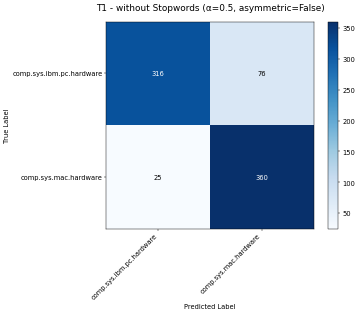


WORD DISTRIBUTION ANALYSIS


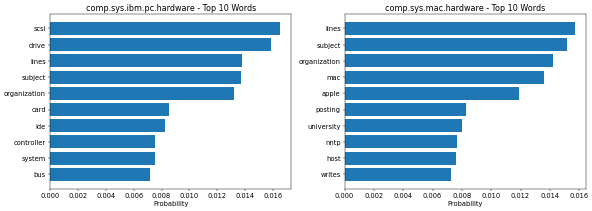


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.194 error rate
    Often confused with: comp.sys.mac.hardware (76 times)
  comp.sys.mac.hardware: 0.065 error rate
    Often confused with: comp.sys.ibm.pc.hardware (25 times)

T1 - without Stopwords (α=0.5, asymmetric=True)
Training Accuracy: 0.9486
Test Accuracy: 0.8687


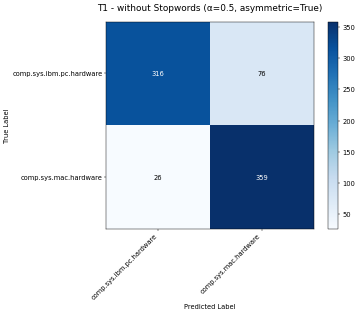


WORD DISTRIBUTION ANALYSIS


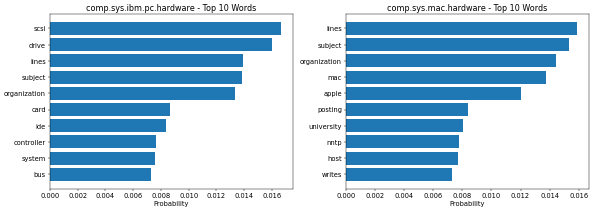


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.194 error rate
    Often confused with: comp.sys.mac.hardware (76 times)
  comp.sys.mac.hardware: 0.068 error rate
    Often confused with: comp.sys.ibm.pc.hardware (26 times)

T1 - without Stopwords (α=2.0, asymmetric=False)
Training Accuracy: 0.9392
Test Accuracy: 0.8649


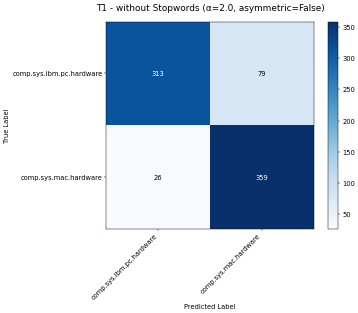


WORD DISTRIBUTION ANALYSIS


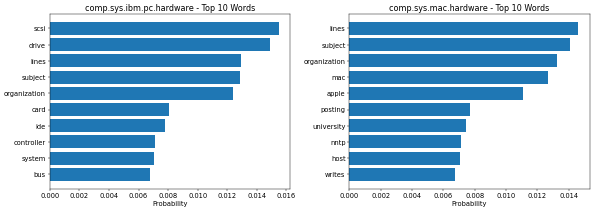


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.202 error rate
    Often confused with: comp.sys.mac.hardware (79 times)
  comp.sys.mac.hardware: 0.068 error rate
    Often confused with: comp.sys.ibm.pc.hardware (26 times)

T1 - without Stopwords (α=2.0, asymmetric=True)
Training Accuracy: 0.9426
Test Accuracy: 0.8687


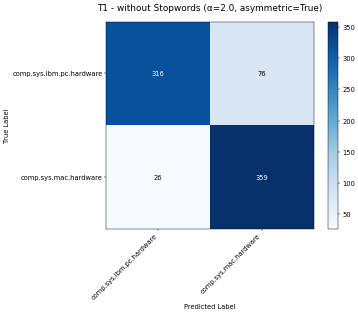


WORD DISTRIBUTION ANALYSIS


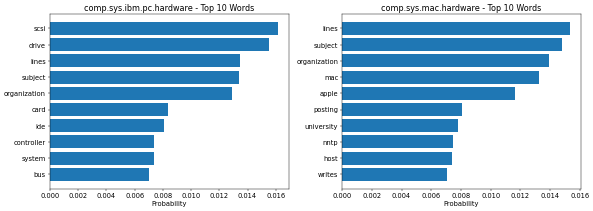


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.194 error rate
    Often confused with: comp.sys.mac.hardware (76 times)
  comp.sys.mac.hardware: 0.068 error rate
    Often confused with: comp.sys.ibm.pc.hardware (26 times)

T1 - without Stopwords (α=5.0, asymmetric=False)
Training Accuracy: 0.9384
Test Accuracy: 0.8571


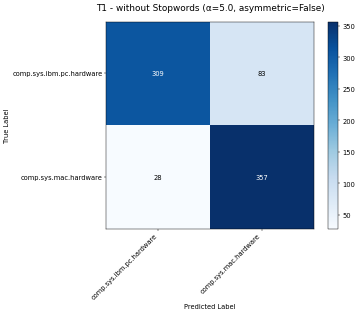


WORD DISTRIBUTION ANALYSIS


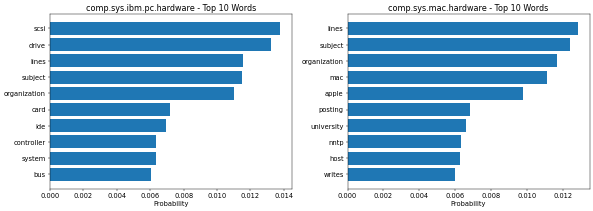


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.212 error rate
    Often confused with: comp.sys.mac.hardware (83 times)
  comp.sys.mac.hardware: 0.073 error rate
    Often confused with: comp.sys.ibm.pc.hardware (28 times)

T1 - without Stopwords (α=5.0, asymmetric=True)
Training Accuracy: 0.9401
Test Accuracy: 0.8649


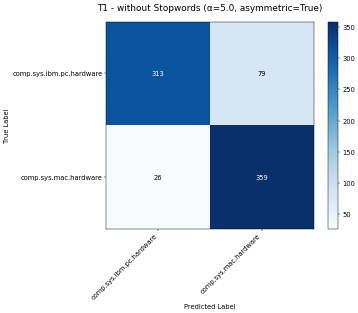


WORD DISTRIBUTION ANALYSIS


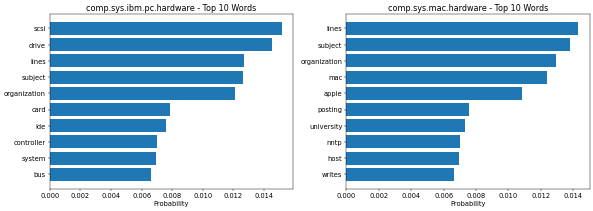


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  comp.sys.ibm.pc.hardware: 0.202 error rate
    Often confused with: comp.sys.mac.hardware (79 times)
  comp.sys.mac.hardware: 0.068 error rate
    Often confused with: comp.sys.ibm.pc.hardware (26 times)

################################################################################
PROCESSING TASK: T2
################################################################################

T2 - with Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9866
Test Accuracy: 0.9648


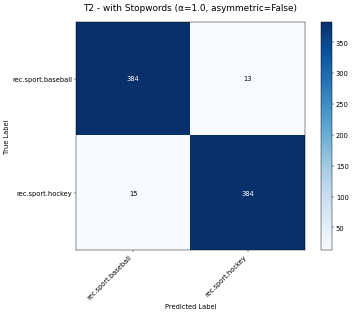


WORD DISTRIBUTION ANALYSIS


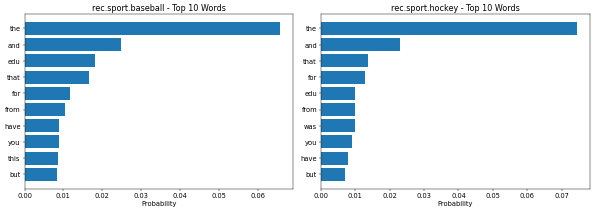


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.038 error rate
    Often confused with: rec.sport.baseball (15 times)
  rec.sport.baseball: 0.033 error rate
    Often confused with: rec.sport.hockey (13 times)

T2 - without Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9916
Test Accuracy: 0.9661


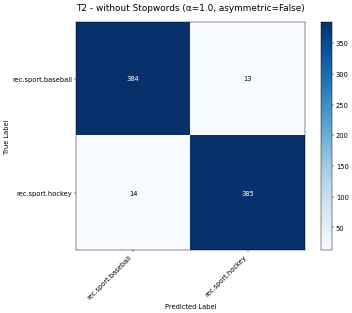


WORD DISTRIBUTION ANALYSIS


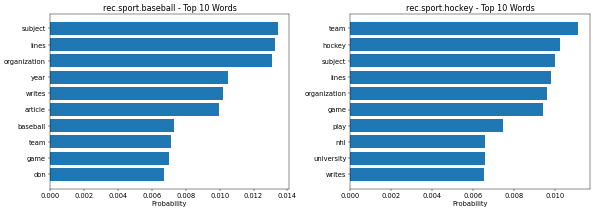


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.035 error rate
    Often confused with: rec.sport.baseball (14 times)
  rec.sport.baseball: 0.033 error rate
    Often confused with: rec.sport.hockey (13 times)

T2 - without Stopwords (α=0.1, asymmetric=False)
Training Accuracy: 0.9933
Test Accuracy: 0.9673


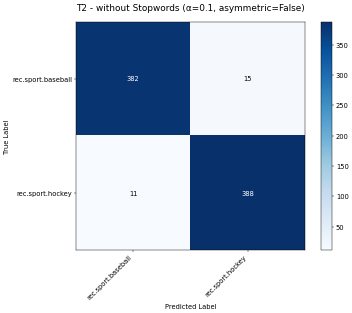


WORD DISTRIBUTION ANALYSIS


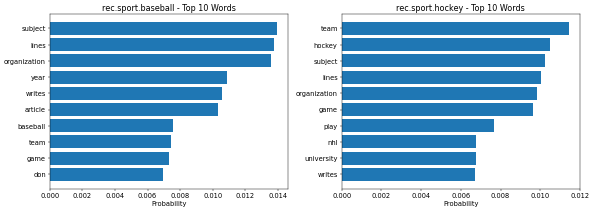


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.baseball: 0.038 error rate
    Often confused with: rec.sport.hockey (15 times)
  rec.sport.hockey: 0.028 error rate
    Often confused with: rec.sport.baseball (11 times)

T2 - without Stopwords (α=0.1, asymmetric=True)
Training Accuracy: 0.9925
Test Accuracy: 0.9673


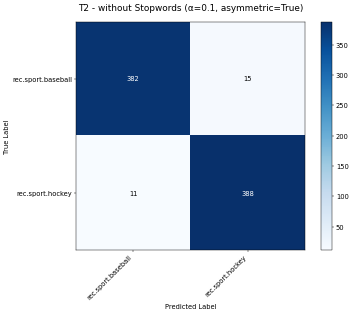


WORD DISTRIBUTION ANALYSIS


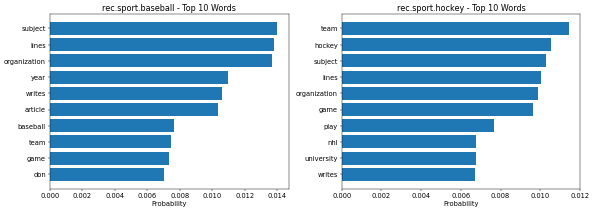


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.baseball: 0.038 error rate
    Often confused with: rec.sport.hockey (15 times)
  rec.sport.hockey: 0.028 error rate
    Often confused with: rec.sport.baseball (11 times)

T2 - without Stopwords (α=0.5, asymmetric=False)
Training Accuracy: 0.9916
Test Accuracy: 0.9661


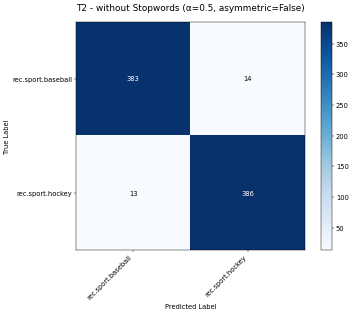


WORD DISTRIBUTION ANALYSIS


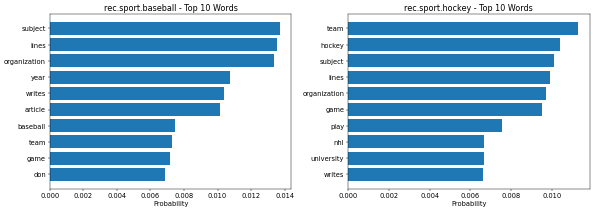


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.baseball: 0.035 error rate
    Often confused with: rec.sport.hockey (14 times)
  rec.sport.hockey: 0.033 error rate
    Often confused with: rec.sport.baseball (13 times)

T2 - without Stopwords (α=0.5, asymmetric=True)
Training Accuracy: 0.9925
Test Accuracy: 0.9661


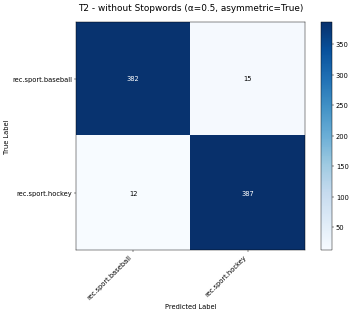


WORD DISTRIBUTION ANALYSIS


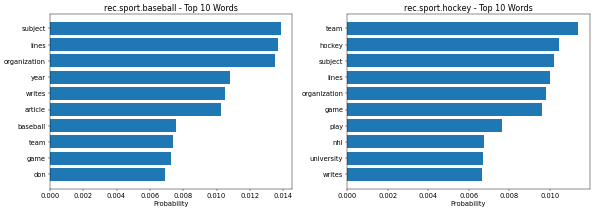


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.baseball: 0.038 error rate
    Often confused with: rec.sport.hockey (15 times)
  rec.sport.hockey: 0.030 error rate
    Often confused with: rec.sport.baseball (12 times)

T2 - without Stopwords (α=2.0, asymmetric=False)
Training Accuracy: 0.9891
Test Accuracy: 0.9648


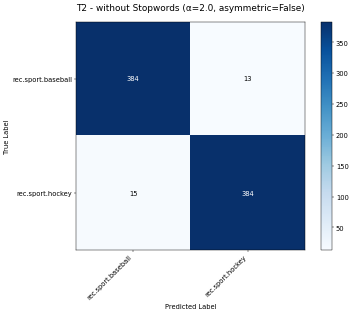


WORD DISTRIBUTION ANALYSIS


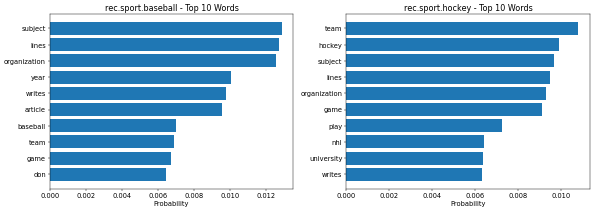


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.038 error rate
    Often confused with: rec.sport.baseball (15 times)
  rec.sport.baseball: 0.033 error rate
    Often confused with: rec.sport.hockey (13 times)

T2 - without Stopwords (α=2.0, asymmetric=True)
Training Accuracy: 0.9916
Test Accuracy: 0.9661


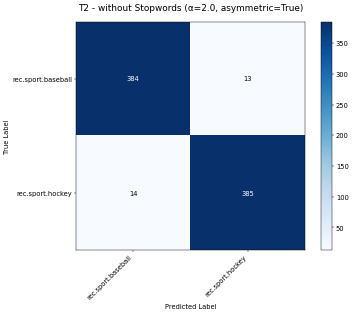


WORD DISTRIBUTION ANALYSIS


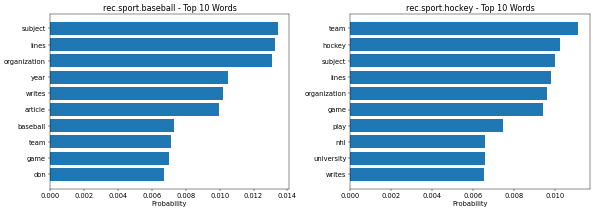


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.035 error rate
    Often confused with: rec.sport.baseball (14 times)
  rec.sport.baseball: 0.033 error rate
    Often confused with: rec.sport.hockey (13 times)

T2 - without Stopwords (α=5.0, asymmetric=False)
Training Accuracy: 0.9875
Test Accuracy: 0.9636


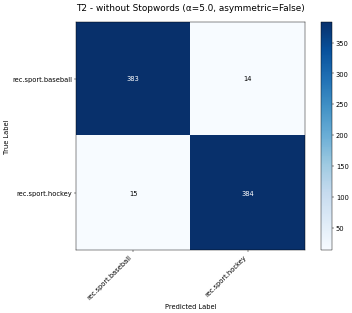


WORD DISTRIBUTION ANALYSIS


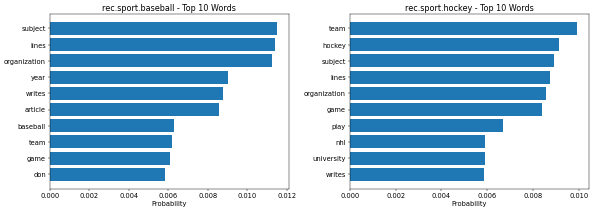


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.038 error rate
    Often confused with: rec.sport.baseball (15 times)
  rec.sport.baseball: 0.035 error rate
    Often confused with: rec.sport.hockey (14 times)

T2 - without Stopwords (α=5.0, asymmetric=True)
Training Accuracy: 0.9891
Test Accuracy: 0.9648


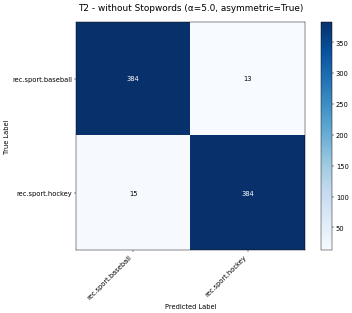


WORD DISTRIBUTION ANALYSIS


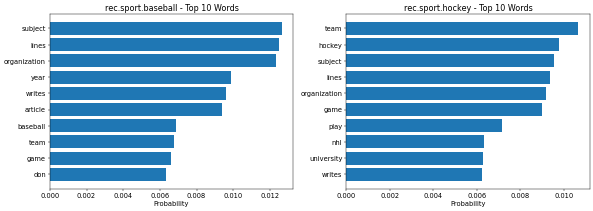


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  rec.sport.hockey: 0.038 error rate
    Often confused with: rec.sport.baseball (15 times)
  rec.sport.baseball: 0.033 error rate
    Often confused with: rec.sport.hockey (13 times)

################################################################################
PROCESSING TASK: T3
################################################################################

T3 - with Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9650
Test Accuracy: 0.9044


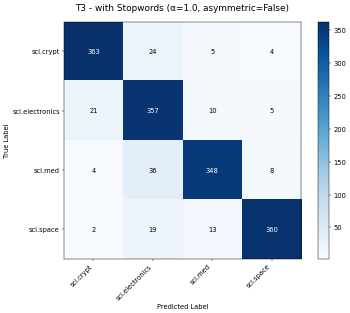


WORD DISTRIBUTION ANALYSIS


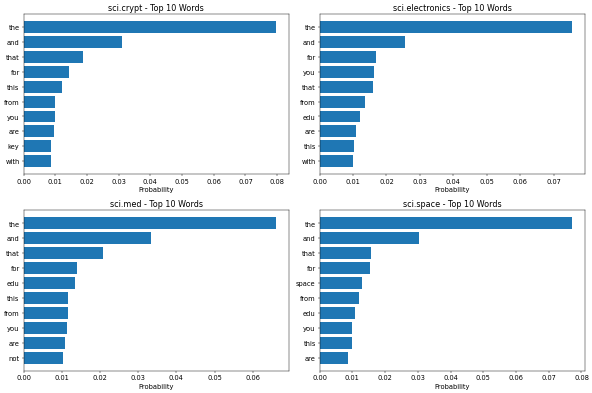


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.121 error rate
    Often confused with: sci.electronics (36 times)
  sci.electronics: 0.092 error rate
    Often confused with: sci.crypt (21 times)
  sci.space: 0.086 error rate
    Often confused with: sci.electronics (19 times)

T3 - without Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9688
Test Accuracy: 0.9158


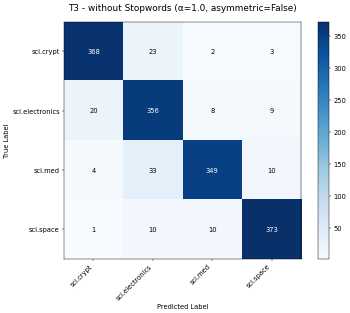


WORD DISTRIBUTION ANALYSIS


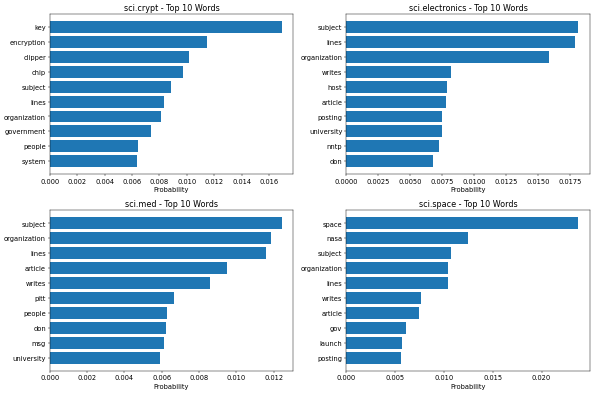


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.119 error rate
    Often confused with: sci.electronics (33 times)
  sci.electronics: 0.094 error rate
    Often confused with: sci.crypt (20 times)
  sci.crypt: 0.071 error rate
    Often confused with: sci.electronics (23 times)

T3 - without Stopwords (α=0.1, asymmetric=False)
Training Accuracy: 0.9730
Test Accuracy: 0.9164


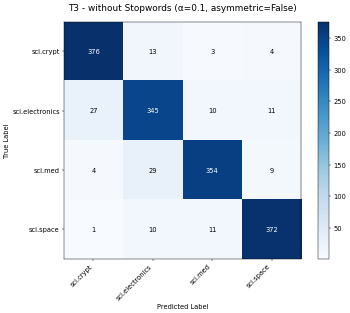


WORD DISTRIBUTION ANALYSIS


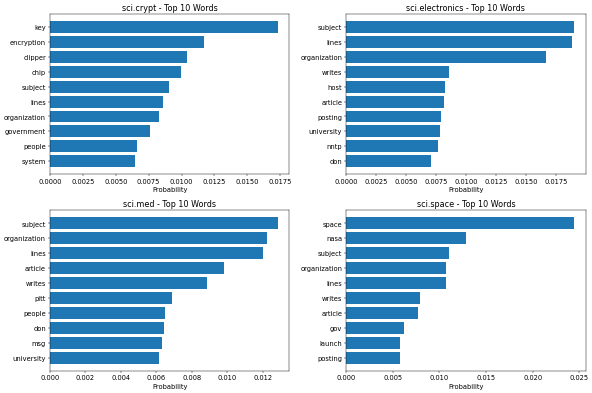


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.electronics: 0.122 error rate
    Often confused with: sci.crypt (27 times)
  sci.med: 0.106 error rate
    Often confused with: sci.electronics (29 times)
  sci.space: 0.056 error rate
    Often confused with: sci.med (11 times)

T3 - without Stopwords (α=0.1, asymmetric=True)
Training Accuracy: 0.9743
Test Accuracy: 0.9145


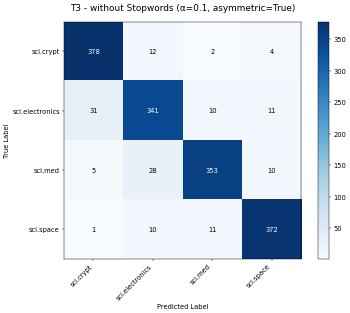


WORD DISTRIBUTION ANALYSIS


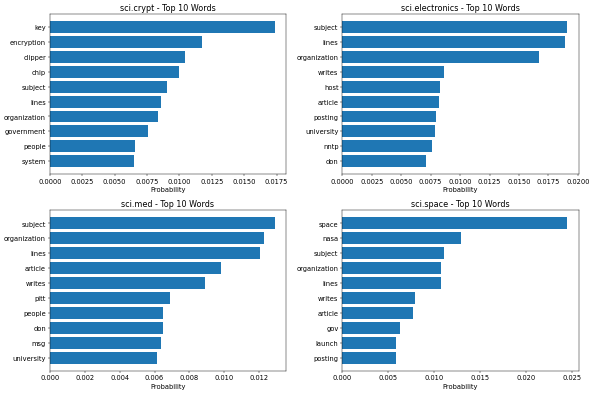


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.electronics: 0.132 error rate
    Often confused with: sci.crypt (31 times)
  sci.med: 0.109 error rate
    Often confused with: sci.electronics (28 times)
  sci.space: 0.056 error rate
    Often confused with: sci.med (11 times)

T3 - without Stopwords (α=0.5, asymmetric=False)
Training Accuracy: 0.9705
Test Accuracy: 0.9189


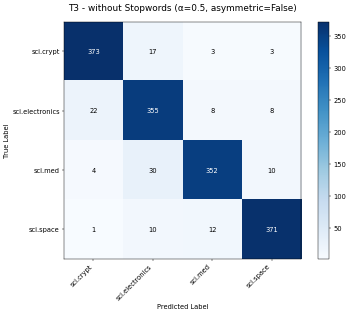


WORD DISTRIBUTION ANALYSIS


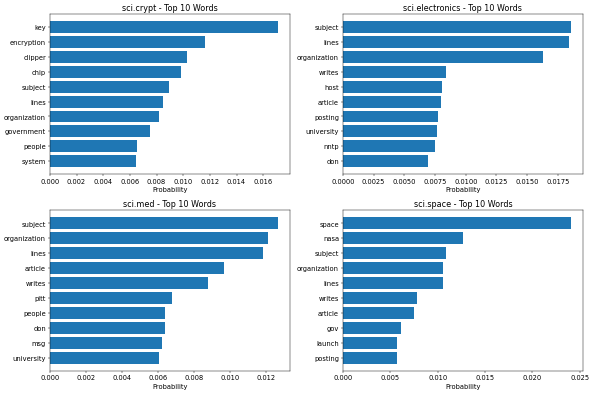


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.111 error rate
    Often confused with: sci.electronics (30 times)
  sci.electronics: 0.097 error rate
    Often confused with: sci.crypt (22 times)
  sci.space: 0.058 error rate
    Often confused with: sci.med (12 times)

T3 - without Stopwords (α=0.5, asymmetric=True)
Training Accuracy: 0.9726
Test Accuracy: 0.9177


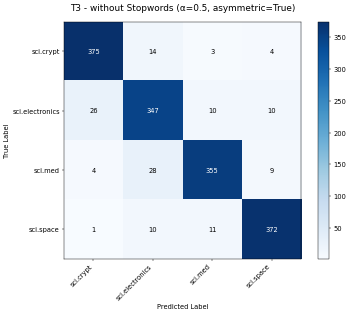


WORD DISTRIBUTION ANALYSIS


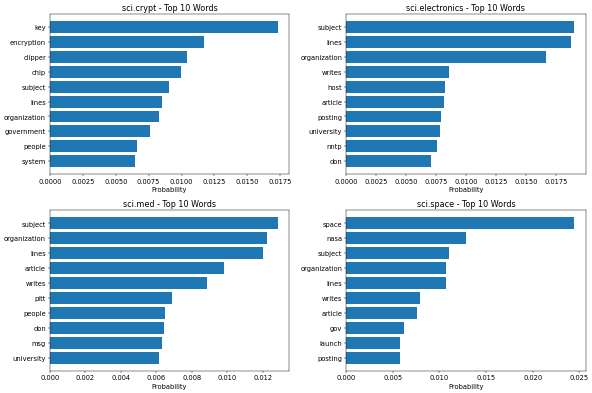


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.electronics: 0.117 error rate
    Often confused with: sci.crypt (26 times)
  sci.med: 0.104 error rate
    Often confused with: sci.electronics (28 times)
  sci.space: 0.056 error rate
    Often confused with: sci.med (11 times)

T3 - without Stopwords (α=2.0, asymmetric=False)
Training Accuracy: 0.9646
Test Accuracy: 0.9126


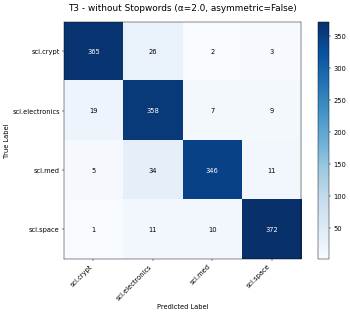


WORD DISTRIBUTION ANALYSIS


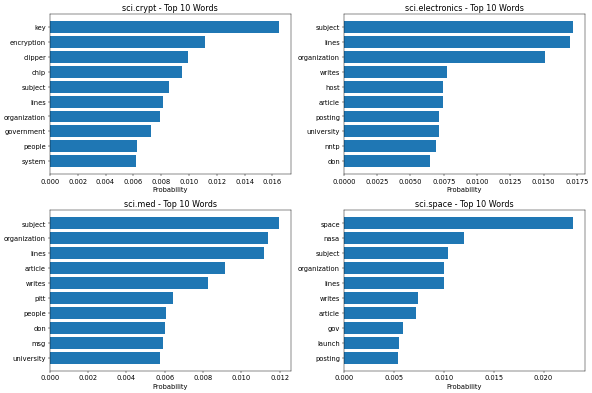


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.126 error rate
    Often confused with: sci.electronics (34 times)
  sci.electronics: 0.089 error rate
    Often confused with: sci.crypt (19 times)
  sci.crypt: 0.078 error rate
    Often confused with: sci.electronics (26 times)

T3 - without Stopwords (α=2.0, asymmetric=True)
Training Accuracy: 0.9705
Test Accuracy: 0.9189


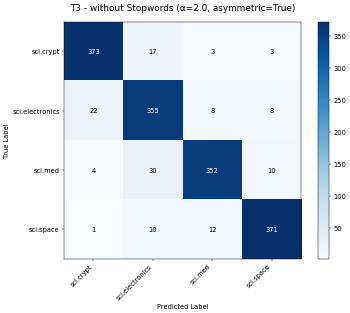


WORD DISTRIBUTION ANALYSIS


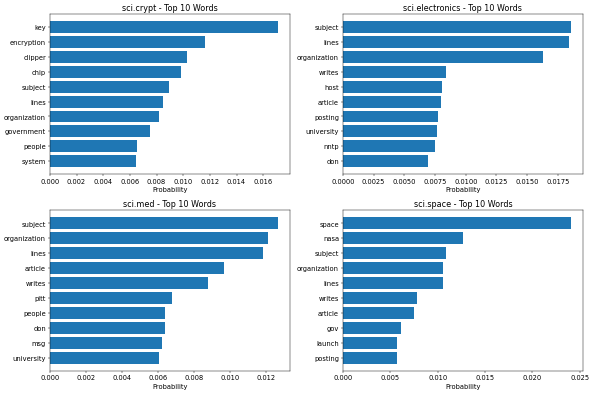


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.111 error rate
    Often confused with: sci.electronics (30 times)
  sci.electronics: 0.097 error rate
    Often confused with: sci.crypt (22 times)
  sci.space: 0.058 error rate
    Often confused with: sci.med (12 times)

T3 - without Stopwords (α=5.0, asymmetric=False)
Training Accuracy: 0.9604
Test Accuracy: 0.9101


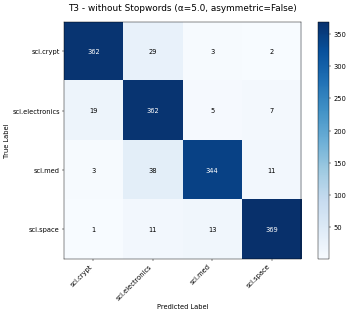


WORD DISTRIBUTION ANALYSIS


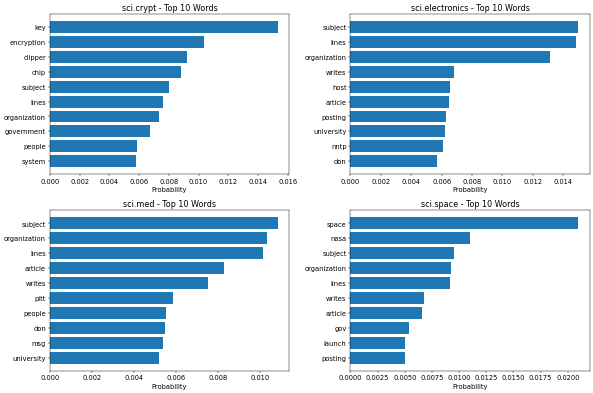


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.131 error rate
    Often confused with: sci.electronics (38 times)
  sci.crypt: 0.086 error rate
    Often confused with: sci.electronics (29 times)
  sci.electronics: 0.079 error rate
    Often confused with: sci.crypt (19 times)

T3 - without Stopwords (α=5.0, asymmetric=True)
Training Accuracy: 0.9676
Test Accuracy: 0.9139


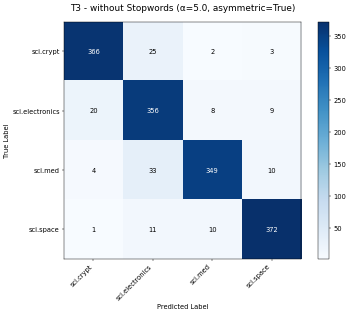


WORD DISTRIBUTION ANALYSIS


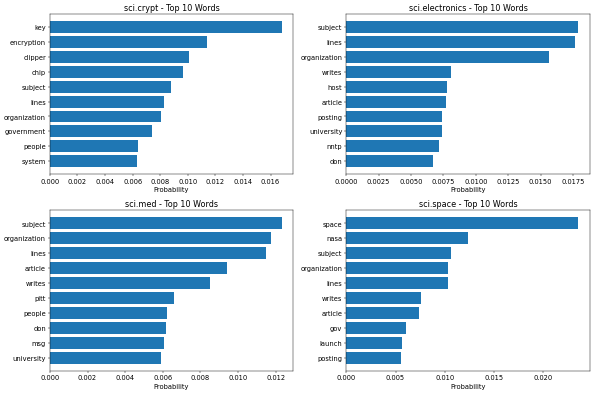


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  sci.med: 0.119 error rate
    Often confused with: sci.electronics (33 times)
  sci.electronics: 0.094 error rate
    Often confused with: sci.crypt (20 times)
  sci.crypt: 0.076 error rate
    Often confused with: sci.electronics (25 times)

################################################################################
PROCESSING TASK: T4
################################################################################

T4 - with Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9787
Test Accuracy: 0.9163


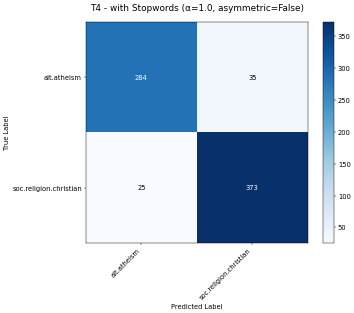


WORD DISTRIBUTION ANALYSIS


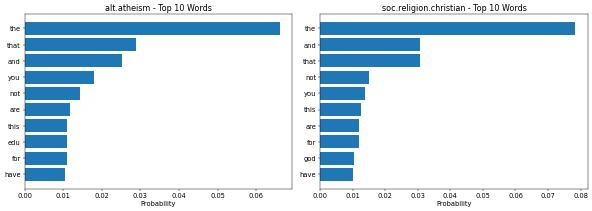


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.110 error rate
    Often confused with: soc.religion.christian (35 times)
  soc.religion.christian: 0.063 error rate
    Often confused with: alt.atheism (25 times)

T4 - without Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9824
Test Accuracy: 0.9219


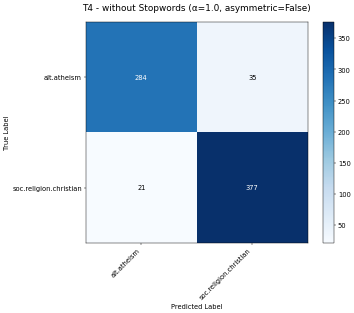


WORD DISTRIBUTION ANALYSIS


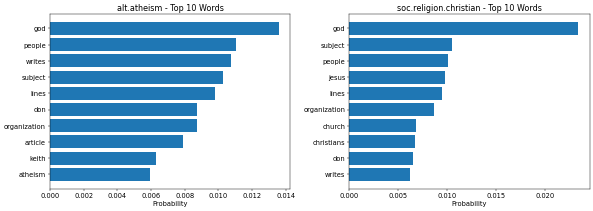


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.110 error rate
    Often confused with: soc.religion.christian (35 times)
  soc.religion.christian: 0.053 error rate
    Often confused with: alt.atheism (21 times)

T4 - without Stopwords (α=0.1, asymmetric=False)
Training Accuracy: 0.9842
Test Accuracy: 0.9303


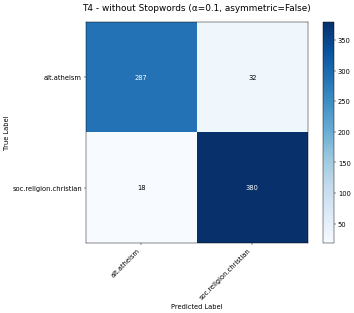


WORD DISTRIBUTION ANALYSIS


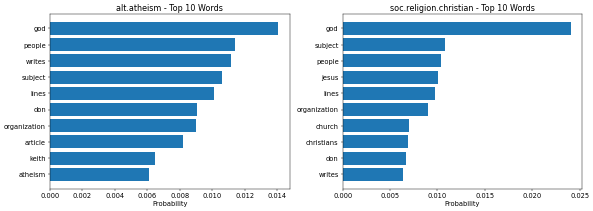


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.100 error rate
    Often confused with: soc.religion.christian (32 times)
  soc.religion.christian: 0.045 error rate
    Often confused with: alt.atheism (18 times)

T4 - without Stopwords (α=0.1, asymmetric=True)
Training Accuracy: 0.9852
Test Accuracy: 0.9303


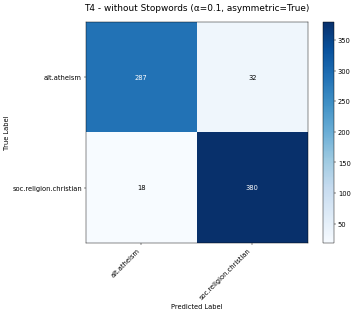


WORD DISTRIBUTION ANALYSIS


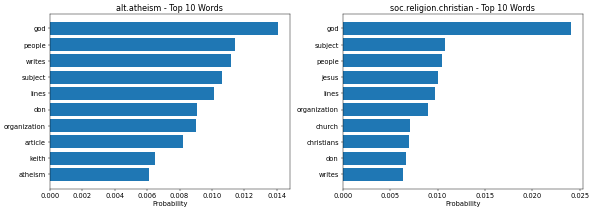


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.100 error rate
    Often confused with: soc.religion.christian (32 times)
  soc.religion.christian: 0.045 error rate
    Often confused with: alt.atheism (18 times)

T4 - without Stopwords (α=0.5, asymmetric=False)
Training Accuracy: 0.9833
Test Accuracy: 0.9219


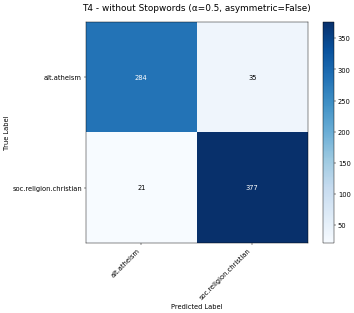


WORD DISTRIBUTION ANALYSIS


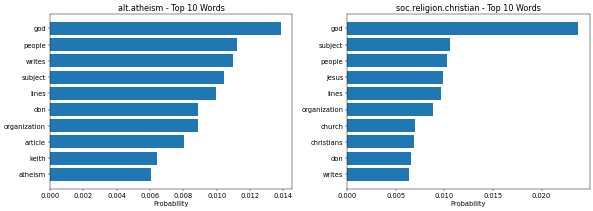


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.110 error rate
    Often confused with: soc.religion.christian (35 times)
  soc.religion.christian: 0.053 error rate
    Often confused with: alt.atheism (21 times)

T4 - without Stopwords (α=0.5, asymmetric=True)
Training Accuracy: 0.9842
Test Accuracy: 0.9233


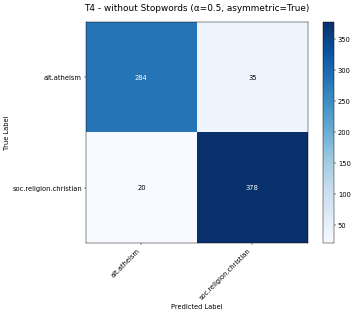


WORD DISTRIBUTION ANALYSIS


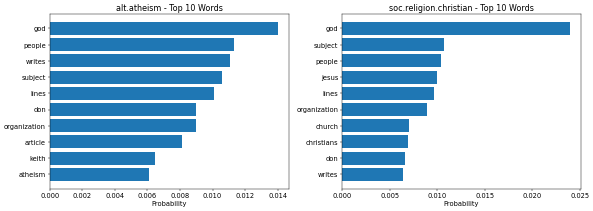


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.110 error rate
    Often confused with: soc.religion.christian (35 times)
  soc.religion.christian: 0.050 error rate
    Often confused with: alt.atheism (20 times)

T4 - without Stopwords (α=2.0, asymmetric=False)
Training Accuracy: 0.9824
Test Accuracy: 0.9163


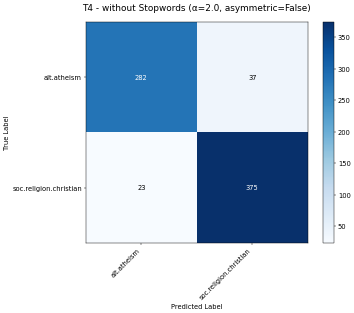


WORD DISTRIBUTION ANALYSIS


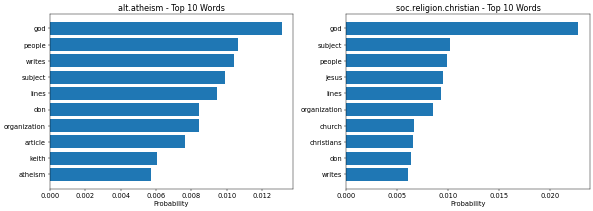


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.116 error rate
    Often confused with: soc.religion.christian (37 times)
  soc.religion.christian: 0.058 error rate
    Often confused with: alt.atheism (23 times)

T4 - without Stopwords (α=2.0, asymmetric=True)
Training Accuracy: 0.9842
Test Accuracy: 0.9219


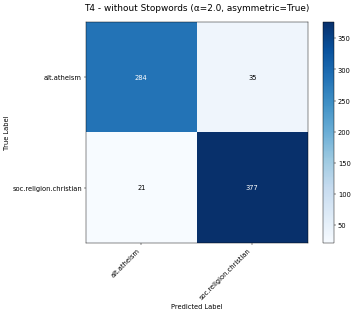


WORD DISTRIBUTION ANALYSIS


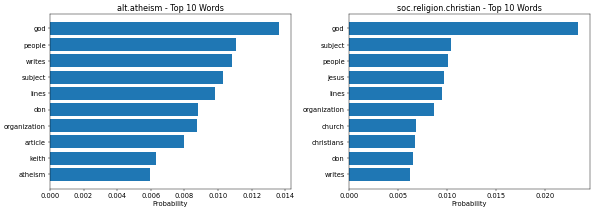


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.110 error rate
    Often confused with: soc.religion.christian (35 times)
  soc.religion.christian: 0.053 error rate
    Often confused with: alt.atheism (21 times)

T4 - without Stopwords (α=5.0, asymmetric=False)
Training Accuracy: 0.9805
Test Accuracy: 0.9163


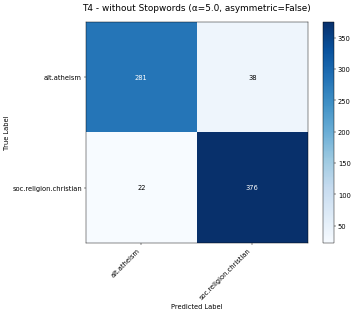


WORD DISTRIBUTION ANALYSIS


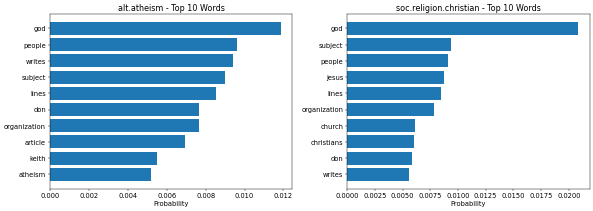


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.119 error rate
    Often confused with: soc.religion.christian (38 times)
  soc.religion.christian: 0.055 error rate
    Often confused with: alt.atheism (22 times)

T4 - without Stopwords (α=5.0, asymmetric=True)
Training Accuracy: 0.9815
Test Accuracy: 0.9177


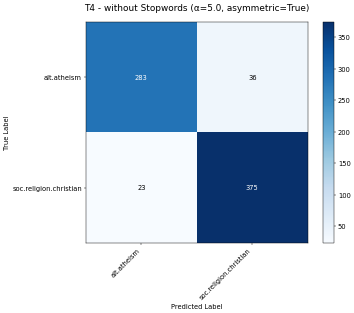


WORD DISTRIBUTION ANALYSIS


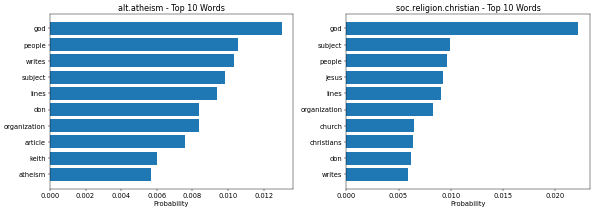


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  alt.atheism: 0.113 error rate
    Often confused with: soc.religion.christian (36 times)
  soc.religion.christian: 0.058 error rate
    Often confused with: alt.atheism (23 times)

################################################################################
PROCESSING TASK: T5
################################################################################

T5 - with Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9594
Test Accuracy: 0.9316


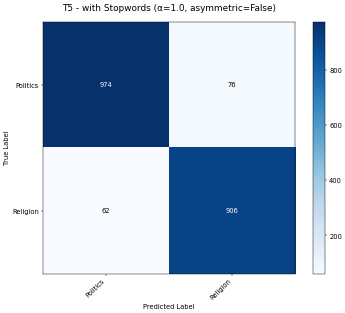


WORD DISTRIBUTION ANALYSIS


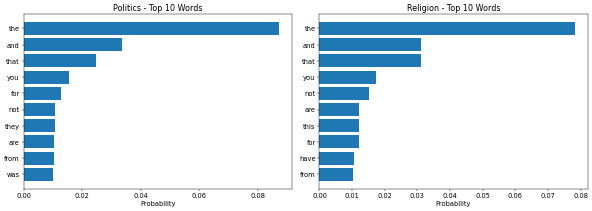


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.072 error rate
    Often confused with: Religion (76 times)
  Religion: 0.064 error rate
    Often confused with: Politics (62 times)

T5 - without Stopwords (α=1.0, asymmetric=False)
Training Accuracy: 0.9630
Test Accuracy: 0.9410


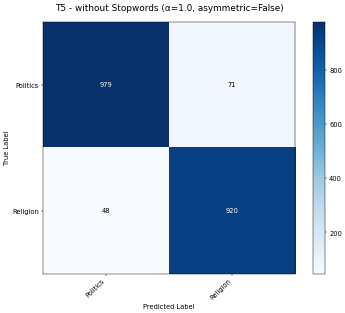


WORD DISTRIBUTION ANALYSIS


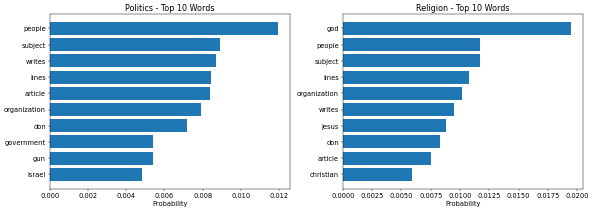


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.068 error rate
    Often confused with: Religion (71 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

T5 - without Stopwords (α=0.1, asymmetric=False)
Training Accuracy: 0.9637
Test Accuracy: 0.9450


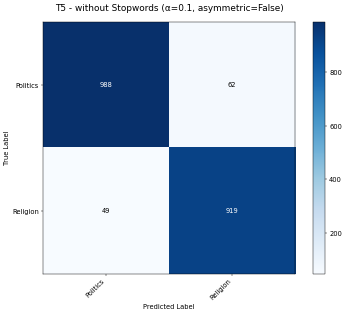


WORD DISTRIBUTION ANALYSIS


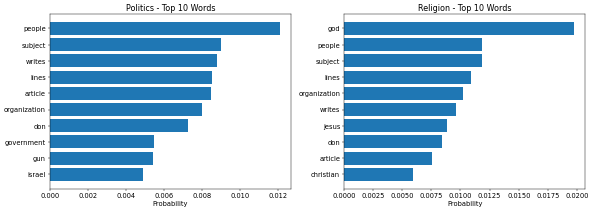


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.059 error rate
    Often confused with: Religion (62 times)
  Religion: 0.051 error rate
    Often confused with: Politics (49 times)

T5 - without Stopwords (α=0.1, asymmetric=True)
Training Accuracy: 0.9640
Test Accuracy: 0.9460


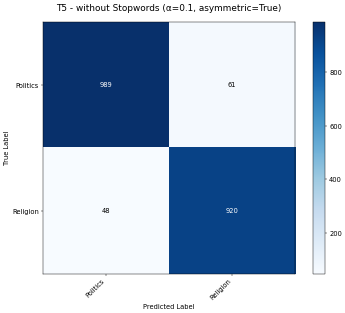


WORD DISTRIBUTION ANALYSIS


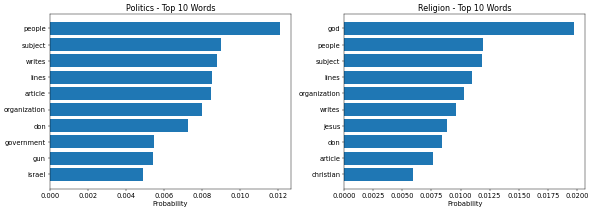


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.058 error rate
    Often confused with: Religion (61 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

T5 - without Stopwords (α=0.5, asymmetric=False)
Training Accuracy: 0.9637
Test Accuracy: 0.9420


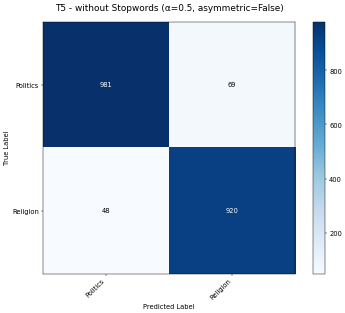


WORD DISTRIBUTION ANALYSIS


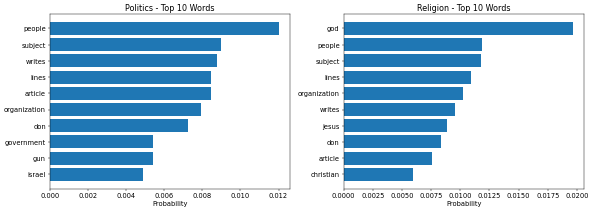


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.066 error rate
    Often confused with: Religion (69 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

T5 - without Stopwords (α=0.5, asymmetric=True)
Training Accuracy: 0.9640
Test Accuracy: 0.9435


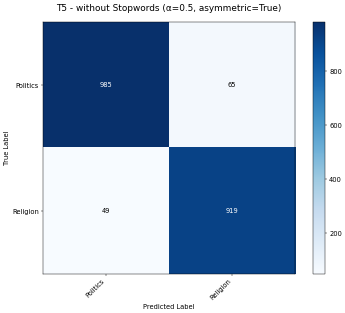


WORD DISTRIBUTION ANALYSIS


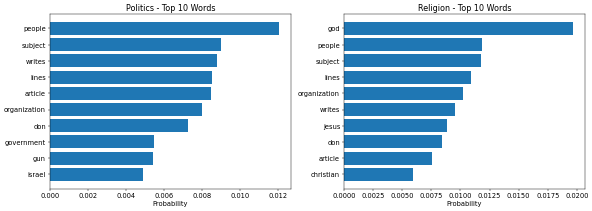


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.062 error rate
    Often confused with: Religion (65 times)
  Religion: 0.051 error rate
    Often confused with: Politics (49 times)

T5 - without Stopwords (α=2.0, asymmetric=False)
Training Accuracy: 0.9621
Test Accuracy: 0.9410


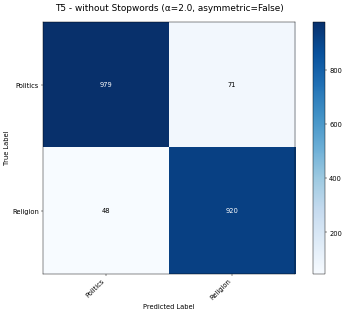


WORD DISTRIBUTION ANALYSIS


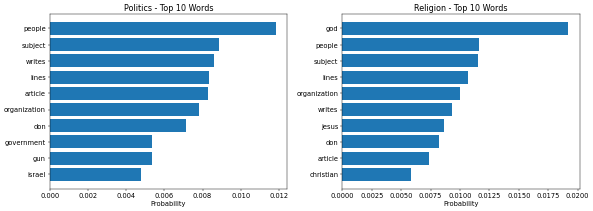


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.068 error rate
    Often confused with: Religion (71 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

T5 - without Stopwords (α=2.0, asymmetric=True)
Training Accuracy: 0.9630
Test Accuracy: 0.9410


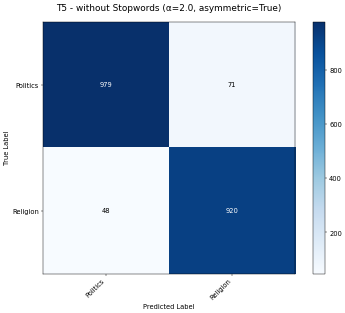


WORD DISTRIBUTION ANALYSIS


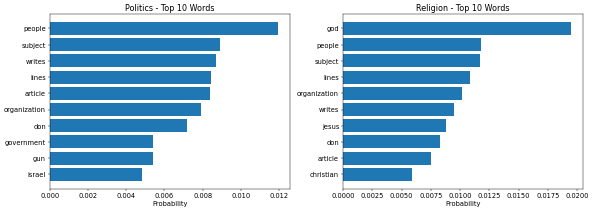


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.068 error rate
    Often confused with: Religion (71 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

T5 - without Stopwords (α=5.0, asymmetric=False)
Training Accuracy: 0.9607
Test Accuracy: 0.9376


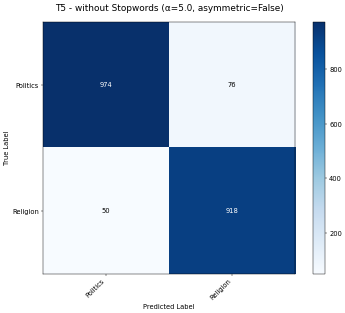


WORD DISTRIBUTION ANALYSIS


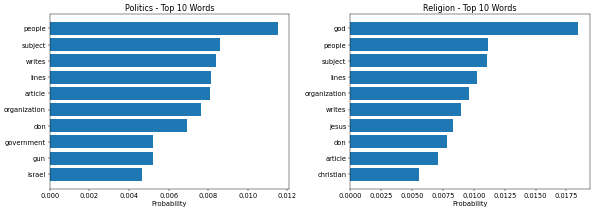


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.072 error rate
    Often confused with: Religion (76 times)
  Religion: 0.052 error rate
    Often confused with: Politics (50 times)

T5 - without Stopwords (α=5.0, asymmetric=True)
Training Accuracy: 0.9624
Test Accuracy: 0.9410


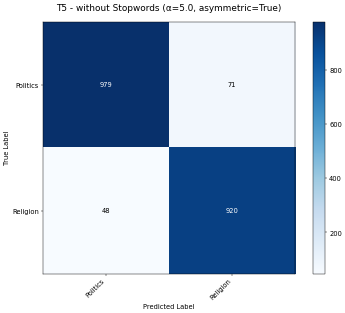


WORD DISTRIBUTION ANALYSIS


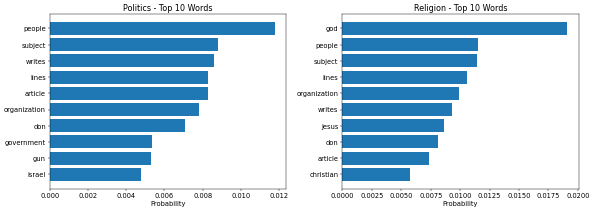


CONFUSION ANALYSIS
Most confusing classes (highest error rates):
  Politics: 0.068 error rate
    Often confused with: Religion (71 times)
  Religion: 0.050 error rate
    Often confused with: Politics (48 times)

################################################################################
FINAL RESULTS SUMMARY
################################################################################

Performance Comparison:
T1: With SW=0.857, Without SW=0.869, Δ=+0.012
T2: With SW=0.965, Without SW=0.966, Δ=+0.001
T3: With SW=0.904, Without SW=0.916, Δ=+0.011
T4: With SW=0.916, Without SW=0.922, Δ=+0.006
T5: With SW=0.932, Without SW=0.941, Δ=+0.009


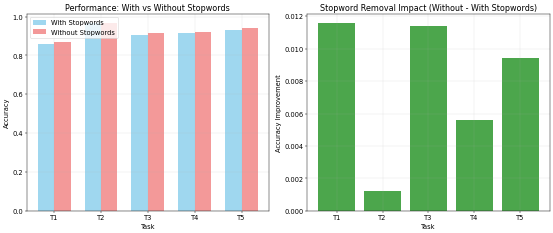


################################################################################
SMOOTHING PARAMETER ANALYSIS
################################################################################


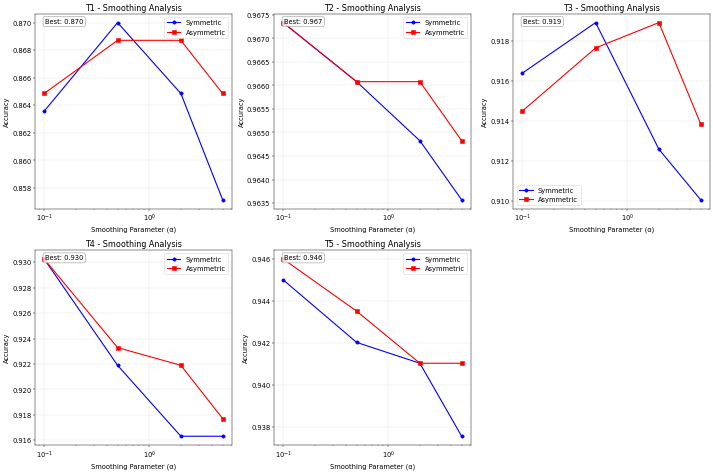


################################################################################
COMPREHENSIVE ANALYSIS REPORT
################################################################################
NAIVE BAYES TEXT CLASSIFICATION - COMPREHENSIVE REPORT
Generated: 2025-09-10 16:14:35.424479

SUMMARY OF RESULTS
----------------------------------------
Task       With SW    Without SW   Improvement  Best Acc  
----------------------------------------
T1         0.857      0.869        +0.012       0.870     
T2         0.965      0.966        +0.001       0.967     
T3         0.904      0.916        +0.011       0.919     
T4         0.916      0.922        +0.006       0.930     
T5         0.932      0.941        +0.009       0.946     

KEY INSIGHTS
----------------------------------------
Average improvement from stopword removal: +0.008
✓ Stopword removal generally improves performance

RECOMMENDATIONS
----------------------------------------
Task T1:
  - Best smoothing: α=0.5, asymmetri

NameError: name 'final_results' is not defined

In [33]:
if __name__ == "__main__":
    main()
    
    print("\nAccessing individual task results:")
    for result in final_results:
        print(f"Task {result['task']}: With SW={result['with_stopwords_acc']:.3f}, "
              f"Without SW={result['without_stopwords_acc']:.3f}")